# project_03_rfdiffusion_monomer — all notebooks (00→05) in one

This is a **convenience copy** that concatenates the six standalone notebooks in order so you can run the whole project top-to-bottom in a single Colab session. The individual notebooks (`00_setup.ipynb` … `05_validation_plan.ipynb`) remain in this folder and are the canonical deliverables. Sections are separated by dividers; each section keeps its own setup/`import` cells (re-running them is harmless). All synthetic numbers are still labeled `EXAMPLE_DATA`.

---

## ▶︎ Section 1 / 6 — `00_setup.ipynb`

---

# 00 · Environment Setup — De Novo Protein Design Capstone

This is the **shared setup notebook** every project starts from. Run it top to bottom
*once per Colab session*. It:

1. detects your GPU and warns if you're on a weak/absent one,
2. installs a light, pinned core toolset (Biopython, py3Dmol, foldseek-less utilities),
3. optionally installs heavier tools (ColabFold, ESMFold) on demand,
4. prints exact versions for your `LOG.md` (reproducibility is graded).

> **Compute reality.** A free Colab **T4** runs ColabFold, ESMFold, ProteinMPNN, and small
> RFdiffusion jobs. **BindCraft / RFantibody / large RFdiffusion** want an **A100** (Colab Pro+
> or a cluster). Each project's `MANUAL.md` states its tier. Don't fight a T4 to do an A100 job —
> plan your batch sizes around it.

## 1 · GPU & environment check

In [1]:
import subprocess, sys, platform, textwrap

def sh(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()

print("Python :", sys.version.split()[0])
print("Platform:", platform.platform())

gpu = sh("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null")
if gpu:
    print("GPU    :", gpu)
    name = gpu.lower()
    if "t4" in name:
        print(textwrap.fill(
            "NOTE: T4 detected. Good for ColabFold/ESMFold/ProteinMPNN/small RFdiffusion. "
            "For BindCraft/RFantibody/large diffusion, switch to A100 (Colab Pro+) or a cluster.", 88))
    elif any(x in name for x in ("a100", "l4", "v100")):
        print("NOTE: capable GPU — heavier tools (BindCraft/RFantibody) are feasible.")
else:
    print("GPU    : NONE FOUND")
    print(textwrap.fill(
        "WARNING: No GPU. Go to Runtime → Change runtime type → Hardware accelerator → GPU. "
        "Structure prediction on CPU is impractically slow.", 88))

Python : 3.11.15
Platform: Linux-6.18.5-x86_64-with-glibc2.39
GPU    : NONE FOUND
Structure prediction on CPU is impractically slow.


## 2 · Pinned core install (fast, T4-friendly)

These are light and used across every project. Pins are conservative; bump them in your repo if needed and **log it**.

In [2]:
# Core utilities used in every project. Quiet + pinned.
%pip -q install biopython==1.84 py3Dmol==2.4.0 numpy pandas matplotlib seaborn tqdm requests 2>/dev/null
print("Core install done.")

Note: you may need to restart the kernel to use updated packages.
Core install done.


In [3]:
# Version stamp — copy this block's output into your LOG.md for reproducibility.
import importlib, datetime
mods = ["Bio", "py3Dmol", "numpy", "pandas", "matplotlib", "seaborn", "tqdm", "requests"]
print("# Environment stamp", datetime.datetime.utcnow().isoformat(timespec="seconds"), "UTC")
for m in mods:
    try:
        v = importlib.import_module(m).__version__
    except Exception:
        v = "n/a"
    print(f"{m:14s} {v}")

# Environment stamp 2026-06-24T03:14:34 UTC
Bio            1.84
py3Dmol        2.4.0


numpy          2.4.6


pandas         3.0.3


matplotlib     3.11.0


seaborn        0.13.2
tqdm           4.68.3
requests       2.33.1


## 3 · Heavy tools — install *on demand*

Don't install these unless your project needs them this session (they're slow to set up).
Each is wrapped in a function so you only pay the cost when you call it.

In [4]:
def install_colabfold():
    """ColabFold (AF2). ~3–5 min on first install. T4 OK."""
    import subprocess
    subprocess.run("pip -q install 'colabfold[alphafold-minus-jax]'", shell=True)
    # On Colab, the standard route is the localcolabfold installer or the ColabFold notebook;
    # here we expose the pip route. If it fails, fall back to the official ColabFold notebook
    # and import your sequences. Log whichever path you used.
    print("ColabFold install attempted. Verify with: from colabfold.batch import run")

def install_esmfold():
    """ESMFold via HuggingFace transformers. T4 OK for <~400 aa."""
    import subprocess
    subprocess.run("pip -q install 'transformers>=4.40' accelerate", shell=True)
    print("ESMFold deps installed. Load with transformers EsmForProteinFolding.")

print("Helpers ready: install_colabfold(), install_esmfold().")

Helpers ready: install_colabfold(), install_esmfold().


## 4 · Reproducibility helpers

Call `set_seeds()` at the top of every run, and use `log()` to append to your `LOG.md`.

In [5]:
import os, random
import numpy as np

def set_seeds(seed: int = 0):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
    print(f"seeds set to {seed}")

def log(msg: str, path: str = "LOG.md"):
    import datetime
    stamp = datetime.datetime.utcnow().isoformat(timespec="seconds")
    with open(path, "a") as fh:
        fh.write(f"- {stamp}Z · {msg}\n")
    print("logged:", msg)

set_seeds(0)
log("Ran 00_setup; environment stamped.")

seeds set to 0
logged: Ran 00_setup; environment stamped.


## 5 · (Optional) Mount Google Drive for persistence

Colab sessions are ephemeral. Mount Drive to keep your `results/` and design pools between sessions.

In [6]:
# from google.colab import drive
# drive.mount("/content/drive")
# WORKDIR = "/content/drive/MyDrive/denovo_capstone/project_XX"
# import os; os.makedirs(WORKDIR, exist_ok=True); os.chdir(WORKDIR)
print("Uncomment to mount Drive and set your working directory.")

Uncomment to mount Drive and set your working directory.


---
**Next:** open `01_define_and_explore.ipynb`. Keep this session alive — re-running `00_setup`
each new session is normal. Record every version and seed in `LOG.md`.

---

## ▶︎ Section 2 / 6 — `01_define_and_explore.ipynb`

---

# 01 · Define & Explore — the novelty↔foldability problem + the toolkit

**Standard slot:** *define & explore.* **For Project 03 this means:** pin down what
self-consistency (scRMSD) and novelty (TM-score) each measure, stand up `rfdiff_tools`, and run the
"hello-world" — generate 10 monomer backbones, measure foldability + novelty, visualize one (D0).

Run `00_setup.ipynb` first in this session.

## The problem in one figure-of-merit pair

Generative models can invent **novel** folds, but novelty trades off against **foldability**. Two
numbers carry the whole project:

| Metric | Range | Means | Does **not** mean |
|--------|-------|-------|-------------------|
| scRMSD | Å | designed-vs-refolded Cα-RMSD (self-consistency / **foldability**); **< 2 Å** = foldable | binding / function / stability |
| pLDDT | 0–100 | local confidence of the refold | thermostability / ΔG |
| TM-score to PDB | 0–1 | structural similarity to nearest natural fold; **< 0.5 ≈ novel** | a pass/fail of correctness — **novelty is a coordinate, not a verdict** |

The deliverable is the **frontier**: how low can TM-score go (more novel) while scRMSD stays < 2 Å
(still foldable)? Write your own one-paragraph definitions in `D0`, including the "does not mean"
column — that is where most published mistakes live.

## Setup paths

In [7]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_03_rfdiffusion_monomer/notebooks


## The backbone-design toolkit

`scripts/rfdiff_tools.py` exposes three functions the campaign uses:
`generate_backbones(length, ss_bias, n, tool)`, `self_consistency(backbone, seq, tool)`, and
`novelty_tm(pdb, tool)`. The real backends (RFdiffusion via ColabDesign, ProteinMPNN, AF2/ESMFold,
Foldseek) need a GPU + heavy installs; a deterministic **mock** backend lets you build and test the
plumbing first. **Never report mock numbers as real designs** — every mock record is flagged
`synthetic=True` and ids are prefixed `EXAMPLE_DATA_`.

In [8]:
import rfdiff_tools as rt

print("campaign grid:")
print("  lengths   :", rt.CAMPAIGN_LENGTHS)
print("  ss_biases :", rt.SS_BIASES)
print("  foldable  : scRMSD <", rt.SELF_CONSISTENT_SCRMSD, "A")
print("  novel     : TM-score <", rt.NOVEL_TM, "to nearest natural fold")

campaign grid:
  lengths   : (80, 120, 200, 300)
  ss_biases : ('alpha', 'beta', 'mixed')
  foldable  : scRMSD < 2.0 A
  novel     : TM-score < 0.5 to nearest natural fold


## Hello-world: generate 10 backbones, score foldability + novelty

Start with the `mock` backend to confirm the plumbing, **then switch `tool="rfdiffusion"`** (and
`"esmfold"`/`"af2"`, `"foldseek"`) on a GPU runtime. The mock numbers encode the project's realistic
priors (short all-α folds best; novelty/length make it harder) so the example looks qualitatively
right — they are **synthetic**, not designs.

In [9]:
import pandas as pd

backbones = rt.generate_backbones(length=80, ss_bias="alpha", n=10, tool="mock", seed=0)

rows = []
for bb in backbones:
    sc = rt.self_consistency(bb, tool="mock")     # ProteinMPNN(8 seqs)->AF2/ESMFold->best scRMSD
    nv = rt.novelty_tm(bb.backbone_id, tool="mock")  # Foldseek/TM-align vs the PDB
    rows.append(dict(backbone_id=bb.backbone_id, length=bb.length, ss_bias=bb.ss_bias,
                     scrmsd=sc.scrmsd, plddt=sc.plddt, tm_to_pdb=nv.tm_to_pdb,
                     synthetic=bb.synthetic))
demo = pd.DataFrame(rows)
demo.to_csv("results/hello_world.csv", index=False)
print("EXAMPLE_DATA (synthetic) — 10 mock backbones:")
print(demo[["backbone_id", "scrmsd", "plddt", "tm_to_pdb"]].to_string(index=False))
print("\nfoldable (scRMSD<2):", int((demo.scrmsd < rt.SELF_CONSISTENT_SCRMSD).sum()), "/ 10",
      "  novel (TM<0.5):", int((demo.tm_to_pdb < rt.NOVEL_TM).sum()), "/ 10")

EXAMPLE_DATA (synthetic) — 10 mock backbones:
               backbone_id  scrmsd  plddt  tm_to_pdb
EXAMPLE_DATA_alpha_L80_000    1.69   80.2      0.506
EXAMPLE_DATA_alpha_L80_001    1.51   82.4      0.560
EXAMPLE_DATA_alpha_L80_002    1.12   87.2      0.635
EXAMPLE_DATA_alpha_L80_003    1.19   86.3      0.491
EXAMPLE_DATA_alpha_L80_004    1.11   87.3      0.624
EXAMPLE_DATA_alpha_L80_005    1.18   86.4      0.284
EXAMPLE_DATA_alpha_L80_006    1.63   80.9      0.458
EXAMPLE_DATA_alpha_L80_007    1.07   87.8      0.588
EXAMPLE_DATA_alpha_L80_008    1.55   81.9      0.588
EXAMPLE_DATA_alpha_L80_009    1.48   82.7      0.537

foldable (scRMSD<2): 10 / 10   novel (TM<0.5): 3 / 10


### Switch to the real backends

Once `00_setup`'s heavy-install helpers have run this session (RFdiffusion via the ColabDesign
notebook; ProteinMPNN; ESMFold/AF2; Foldseek), change `tool="mock"` to the real backends and rerun.
ESMFold is the fastest refold (no MSA), so use it for triage and AF2 for top picks. **Compute
honesty:** a T4 handles a small batch like this; the *full* campaign in notebook 02 needs an
A100/HPC. Record runtime + the GPU + the pinned commits in `LOG.md`.

In [10]:
# Uncomment after installing the real backends in 00_setup (GPU runtime):
# real = rt.generate_backbones(length=80, ss_bias="alpha", n=10, tool="rfdiffusion", seed=0)
# sc = rt.self_consistency(real[0], tool="esmfold")   # ProteinMPNN -> ESMFold -> scRMSD
# nv = rt.novelty_tm(real[0].pdb_path, tool="foldseek", db="pdb_db")
# print(sc, nv)
print("Ready — flip tool='mock' to the real backends on a GPU runtime (A100/HPC for the full sweep).")

Ready — flip tool='mock' to the real backends on a GPU runtime (A100/HPC for the full sweep).


## Visualize a backbone (py3Dmol)

Use this to eyeball any generated/predicted backbone PDB once you have one. (The mock backend writes
no PDB; this is for real runs.)

In [11]:
import py3Dmol

def show_pdb(pdb_path_or_str, is_path=True):
    data = open(pdb_path_or_str).read() if is_path else pdb_path_or_str
    view = py3Dmol.view(width=500, height=400)
    view.addModel(data, "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    view.zoomTo()
    return view.show()

# Example (after a real RFdiffusion run):
# show_pdb(real[0].pdb_path)
print("show_pdb(pdb_path) ready — use it on a real backbone PDB.")

show_pdb(pdb_path) ready — use it on a real backbone PDB.


## D0 checklist
- [ ] One-paragraph definition of **scRMSD** and **TM-score/novelty**, each **with** its "does not mean" note (novelty ≠ correctness).
- [ ] Reproduced the 10-backbone hello-world (mock here; one real RFdiffusion→MPNN→refold→Foldseek pass on a GPU runtime).
- [ ] Problem statement with measurable criteria (scRMSD < 2 Å foldable; TM < 0.5 novel) + the controls you'll need.
- [ ] `LOG.md` entry: tool versions/commits, GPU, runtime, seed.

**Next:** `02_generate.ipynb` — run the campaign across lengths × secondary-structure biases.

---

## ▶︎ Section 3 / 6 — `02_generate.ipynb`

---

# 02 · Campaign — generate across lengths × secondary-structure biases

**Standard slot:** *design campaign.* **For Project 03 this means:** the core generative campaign —
hundreds of RFdiffusion monomer backbones across lengths {80,120,200,300} and SS-biases {α,β,mixed},
each redesigned with ProteinMPNN (8 seqs) and refolded for self-consistency, written to
`results/backbones.csv` (D2). **Diversity before filtering.**

> **Compute reality.** This runs **anywhere on the `mock` backend** (no GPU). The *real* campaign:
> a free **T4 handles small batches only**; the full lengths×topology sweep (100s of backbones,
> lengths up to 300) realistically needs an **A100 / HPC**. Batch overnight; do not fight a T4.

## Setup paths

In [12]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_03_rfdiffusion_monomer/notebooks


## Version-verify cell (pinned upstreams — tools change)

These tools move; pin a commit/tag and HTTP-check the upstreams still exist before a run. Replace the
`# pinned:` comments with the exact commit/tag you used and log them in `LOG.md`.

In [13]:
import requests

PINNED_UPSTREAMS = {
    # tool          : (url, "pinned commit/tag — REPLACE with the one you used")
    "RFdiffusion":  ("https://github.com/RosettaCommons/RFdiffusion", "pin a commit/tag"),
    "ColabDesign":  ("https://github.com/sokrypton/ColabDesign",      "pin a commit/tag"),
    "Foldseek":     ("https://github.com/steineggerlab/foldseek",     "pin a release"),
}
for tool, (url, pin) in PINNED_UPSTREAMS.items():
    try:
        r = requests.head(url, allow_redirects=True, timeout=20)
        print(f"  {tool:12s} {r.status_code}  {url}  (pinned: {pin})")
    except Exception as e:
        print(f"  {tool:12s} CHECK FAILED ({e!r})  {url}")
print("\nIf any is not 200, the repo moved/renamed — update the install + the pin, and log it.")

  RFdiffusion  200  https://github.com/RosettaCommons/RFdiffusion  (pinned: pin a commit/tag)


  ColabDesign  200  https://github.com/sokrypton/ColabDesign  (pinned: pin a commit/tag)


  Foldseek     200  https://github.com/steineggerlab/foldseek  (pinned: pin a release)

If any is not 200, the repo moved/renamed — update the install + the pin, and log it.


## 1 · The campaign grid

Generate `N_PER_CELL` backbones in every (length × ss_bias) cell. On the `mock` backend keep it
small so the notebook is fast; on the real backend scale `N_PER_CELL` up (the catalog asks for
*hundreds* of backbones total) and move to A100/HPC.

In [14]:
import rfdiff_tools as rt
import pandas as pd

LENGTHS  = rt.CAMPAIGN_LENGTHS      # (80, 120, 200, 300)
SS_BIAS  = rt.SS_BIASES             # ("alpha", "beta", "mixed")
N_PER_CELL = 8                      # mock: small & fast. Real: scale to dozens -> 100s total (A100/HPC).
TOOL_GEN   = "mock"                 # -> "rfdiffusion" on a GPU runtime
TOOL_FOLD  = "mock"                 # -> "esmfold" (triage) / "af2" (top picks)
TOOL_NOV   = "mock"                 # -> "foldseek"
SEED       = 0

print(f"grid: {len(LENGTHS)} lengths x {len(SS_BIAS)} topologies x {N_PER_CELL} = "
      f"{len(LENGTHS)*len(SS_BIAS)*N_PER_CELL} backbones (mock run)")

grid: 4 lengths x 3 topologies x 8 = 96 backbones (mock run)


## 2 · Run: generate → ProteinMPNN → self-consistency → novelty

For each backbone: ProteinMPNN designs ~8 sequences, each is refolded (AF2/ESMFold), and we keep the
**best-of-8 scRMSD**; Foldseek/TM-align scores novelty against the PDB. The mock backend folds this
into one deterministic call per backbone so the loop runs anywhere — **the numbers are synthetic
(`EXAMPLE_DATA_`)**, encoding the realistic prior that short all-α folds best and long all-β worst.

In [15]:
rows = []
for L in LENGTHS:
    for ss in SS_BIAS:
        bbs = rt.generate_backbones(length=L, ss_bias=ss, n=N_PER_CELL, tool=TOOL_GEN, seed=SEED)
        for bb in bbs:
            sc = rt.self_consistency(bb, tool=TOOL_FOLD, n_seqs=8)   # best-of-8 MPNN seqs
            nv = rt.novelty_tm(bb.pdb_path or bb.backbone_id, tool=TOOL_NOV)
            rows.append(dict(
                backbone_id=bb.backbone_id, length=L, ss_bias=ss, seed=bb.seed,
                scrmsd=sc.scrmsd, plddt=sc.plddt, tm_to_pdb=nv.tm_to_pdb,
                synthetic=bb.synthetic, tool_gen=bb.tool, tool_fold=sc.tool, tool_nov=nv.tool))

backbones = pd.DataFrame(rows)
backbones.to_csv("results/backbones.csv", index=False)
print("wrote results/backbones.csv", backbones.shape)
backbones.head()

wrote results/backbones.csv (96, 11)


,backbone_id,length,ss_bias,seed,scrmsd,plddt,tm_to_pdb,synthetic,tool_gen,tool_fold,tool_nov
0,EXAMPLE_DATA_alpha_L80_000,80,alpha,0,1.69,80.2,0.506,True,mock,mock,mock
1,EXAMPLE_DATA_alpha_L80_001,80,alpha,0,1.51,82.4,0.560,True,mock,mock,mock
2,EXAMPLE_DATA_alpha_L80_002,80,alpha,0,1.12,87.2,0.635,True,mock,mock,mock
3,EXAMPLE_DATA_alpha_L80_003,80,alpha,0,1.19,86.3,0.491,True,mock,mock,mock
4,EXAMPLE_DATA_alpha_L80_004,80,alpha,0,1.11,87.3,0.624,True,mock,mock,mock


## 3 · First look at the campaign

Foldability rate per cell (fraction with scRMSD < 2 Å). On the synthetic mock data you should see the
expected pattern: high for short all-α, collapsing toward long all-β. **This per-cell rate IS the
result** — notebook 04 turns it into the frontier.

In [16]:
import rfdiff_tools as rt
foldable = backbones.assign(foldable=backbones.scrmsd < rt.SELF_CONSISTENT_SCRMSD)
rate = (foldable.groupby(["ss_bias", "length"])["foldable"].mean()
        .unstack("length").round(2))
print("EXAMPLE_DATA (synthetic) — foldable rate (scRMSD < 2 A) by topology x length:")
print(rate)
print("\nnovel (TM<0.5) overall:", int((backbones.tm_to_pdb < rt.NOVEL_TM).sum()),
      "/", len(backbones))

EXAMPLE_DATA (synthetic) — foldable rate (scRMSD < 2 A) by topology x length:
length    80    120   200  300
ss_bias                       
alpha    1.00  1.00  0.62  0.0
beta     0.00  0.25  0.00  0.0
mixed    0.75  0.50  0.25  0.0

novel (TM<0.5) overall: 43 / 96


## 4 · The real RFdiffusion call (ColabDesign) + A100 note

On a GPU runtime, swap the mock backend for the real one. The pattern below shows the ColabDesign
RFdiffusion call `generate_backbones` wraps; see `scripts/rfdiff_tools.py` for the adapter TODOs.

In [17]:
# Real backend (GPU runtime; A100/HPC for the full sweep). Illustrative — fill in 00_setup installs.
#
#   # via the ColabDesign RFdiffusion notebook (pin the commit):
#   ./run_inference.py 'contigmap.contigs=[80-80]' inference.num_designs=8 \
#       inference.output_prefix=results/backbones/len80_alpha \
#       'scaffoldguided.ss_bias=alpha'
#
# then in this notebook:
#   TOOL_GEN, TOOL_FOLD, TOOL_NOV = "rfdiffusion", "esmfold", "foldseek"
#   # ESMFold for triage across the whole pool; re-fold top picks with AF2 in notebook 04.
#
# COMPUTE: T4 OK for a single cell / small n. The full 4 lengths x 3 topologies x dozens
# realistically needs an A100 (Colab Pro+) or HPC. Batch overnight; log GPU + runtime per cell.
print("Real campaign: set TOOL_* to the real backends on A100/HPC; batch the full grid overnight.")

Real campaign: set TOOL_* to the real backends on A100/HPC; batch the full grid overnight.


## D2 checklist
- [ ] `results/backbones.csv`: hundreds of backbones across the full lengths × SS-bias grid (real run), one row per backbone with length, ss_bias, scrmsd, plddt, tm_to_pdb, seed.
- [ ] Design log: every config (length, ss_bias, num_designs), MPNN settings (temp, seqs/backbone), seeds, GPU, runtimes in `LOG.md`.
- [ ] Version-verify cell run; pinned commits recorded.
- [ ] Per-cell foldability rate inspected (don't leave under-sampled cells — esp. long all-β).
- [ ] 3–4 page interim report on the early frontier shape.

**Next:** `03_filter_and_rank.ipynb` — run the shared filter on your backbone pool.

---

## ▶︎ Section 4 / 6 — `03_filter_and_rank.ipynb`

---

# 03 · Filter & Rank — run the shared multi-layer filter

**Standard slot:** *filter & rank* via `shared/filtering_pipeline.py` — the same module all 25
projects use. **For Project 03** you filter the backbone pool on **foldability** (scRMSD/pLDDT) with
`design_type="monomer"`, and **report novelty (TM-score) as a coordinate, not a pass/fail**.

Run `00`–`02` first so `results/backbones.csv` exists.

## Setup paths

In [18]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_03_rfdiffusion_monomer/notebooks


## Load the shared filtering pipeline
This is the cohort's shared module — improvements here are pull-requested back for everyone. For
monomers the relevant cutoffs are `scrmsd` and `plddt`; `tm_to_pdb` is carried through and reported,
never used as a gate.

In [19]:
import filtering_pipeline as fp
import pandas as pd

print("DEFAULT_CUTOFFS['monomer']:", fp.DEFAULT_CUTOFFS["monomer"])
print("(scrmsd<2.0 foldable; plddt>85 confident; TM-score is REPORTED, not filtered)")

DEFAULT_CUTOFFS['monomer']: {'scrmsd': 2.0, 'plddt': 85, 'pae': None}
(scrmsd<2.0 foldable; plddt>85 confident; TM-score is REPORTED, not filtered)


## Build `fp.Design` objects (monomer)

Map each backbone row onto an `fp.Design` with `design_type="monomer"`, populating `scrmsd`, `plddt`,
and `tm_to_pdb`. We pass `scrmsd` directly (computed in nb 02 from designed-vs-refolded Cα-RMSD), so
`self_consistency()` uses the provided value. We do **not** set `tm_to_pdb` as a cutoff anywhere —
it rides along for the frontier in nb 04.

In [20]:
backbones = pd.read_csv("results/backbones.csv")

designs = []
for _, r in backbones.iterrows():
    designs.append(fp.Design(
        design_id=str(r["backbone_id"]),
        sequence="",                       # not needed for the foldability layers
        design_type="monomer",
        scrmsd=(None if pd.isna(r["scrmsd"]) else float(r["scrmsd"])),
        plddt=(None if pd.isna(r["plddt"]) else float(r["plddt"])),
        tm_to_pdb=(None if pd.isna(r["tm_to_pdb"]) else float(r["tm_to_pdb"])),
        extra={"length": int(r["length"]), "ss_bias": r["ss_bias"],
               "synthetic": bool(r.get("synthetic", False))},
    ))
print(len(designs), "Design objects built (design_type='monomer')")

96 Design objects built (design_type='monomer')


## Run the pipeline (foldability gates; novelty reported)

`run_pipeline(..., design_type="monomer")` applies the layers in order and returns a ranked
DataFrame. We use the self-consistency layer (L1) as the foldability gate. (Layers 2–3 need an
orthogonal refold / solubility, added in nb 04; here L1 is the point.) `report()` prints hit-rate
accounting + the survival figure and writes the ranked CSV.

Total designs: 96
  L1 survivors: 14  (14.6%)


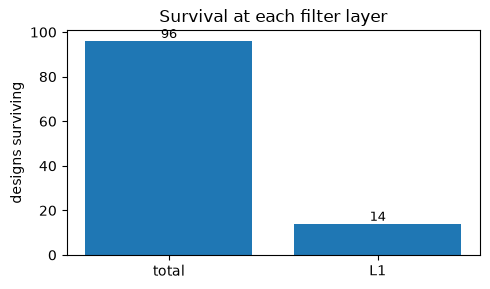


Note: tm_to_pdb is shown for context — it is NOT a pass/fail criterion.


,design_id,design_type,layers_passed,score,scrmsd,plddt,pae_interaction,rosetta_dG,tm_to_pdb
0,EXAMPLE_DATA_alpha_L120_006,monomer,1,2.690,0.96,90.0,None,None,0.287
1,EXAMPLE_DATA_alpha_L80_007,monomer,1,2.558,1.07,87.8,None,None,0.588
2,EXAMPLE_DATA_alpha_L80_004,monomer,1,2.513,1.11,87.3,None,None,0.624
3,EXAMPLE_DATA_alpha_L80_002,monomer,1,2.502,1.12,87.2,None,None,0.635
4,EXAMPLE_DATA_alpha_L120_000,monomer,1,2.477,1.15,87.7,None,None,0.243
5,EXAMPLE_DATA_alpha_L80_005,monomer,1,2.434,1.18,86.4,None,None,0.284
6,EXAMPLE_DATA_alpha_L80_003,monomer,1,2.423,1.19,86.3,None,None,0.491
7,EXAMPLE_DATA_alpha_L120_007,monomer,1,2.420,1.20,87.0,None,None,0.492
8,EXAMPLE_DATA_alpha_L120_002,monomer,1,2.376,1.24,86.6,None,None,0.320
9,EXAMPLE_DATA_mixed_L80_003,monomer,1,2.373,1.25,87.3,None,None,0.524


In [21]:
df_ranked = fp.run_pipeline(designs, design_type="monomer", use_layers=(1,))
df_ranked.to_csv("results/ranked.csv", index=False)
top = fp.report(df_ranked, top_n=10, save_prefix="results/proj03")
print("\nNote: tm_to_pdb is shown for context — it is NOT a pass/fail criterion.")
top

## Survival + novelty-of-survivors (honest accounting)

How many backbones pass the foldability gate, and — crucially for this project — **what novelty did
the survivors have?** A filter that only passes conservative (high-TM) folds has spent no novelty
budget. Break the survival down by topology; that breakdown is the result.

In [22]:
import rfdiff_tools as rt

passed = df_ranked[df_ranked["layers_passed"] >= 1]
print("foldable (passed L1):", len(passed), "/", len(df_ranked))
if "tm_to_pdb" in passed and passed["tm_to_pdb"].notna().any():
    novel_survivors = passed[passed["tm_to_pdb"] < rt.NOVEL_TM]
    print("  of which NOVEL (TM<0.5):", len(novel_survivors),
          "-> these are the novel-but-foldable designs the project is after")
# survival by topology (extra dict was flattened into the DataFrame by asdict)
if "extra" in df_ranked.columns:
    df_ranked["ss_bias"] = df_ranked["extra"].apply(
        lambda d: d.get("ss_bias") if isinstance(d, dict) else None)
    print("\nfoldable count by topology:")
    print(df_ranked.assign(folded=df_ranked["layers_passed"] >= 1)
          .groupby("ss_bias")["folded"].agg(["sum", "count"]))

foldable (passed L1): 14 / 96
  of which NOVEL (TM<0.5): 8 -> these are the novel-but-foldable designs the project is after

foldable count by topology:
         sum  count
ss_bias            
alpha     11     32
beta       0     32
mixed      3     32


## D3 (part 1) checklist
- [ ] `results/ranked.csv` produced by the **shared** module (`filtering_pipeline`), not a one-off script.
- [ ] Foldability (scRMSD<2, pLDDT>85) used as the gate; **novelty (TM-score) reported, never filtered**.
- [ ] Survival reported, broken down by topology; novelty of the survivors noted.
- [ ] Any mapping assumptions (best-of-8 scRMSD, which refold tool) written down.

**Next:** `04_validate.ipynb` — the novelty-vs-scRMSD frontier + tool comparison.

---

## ▶︎ Section 5 / 6 — `04_validate.ipynb`

---

# 04 · Validate — the novelty-vs-scRMSD frontier + tool comparison

**Standard slot:** *validate (in silico).* **For Project 03 this is the core science:** the
**novelty-vs-foldability Pareto frontier**, per-topology and per-length success rates, and an honest
RFdiffusion / FrameFlow / Genie2 comparison scaffold (D3 part 2).

Needs `results/backbones.csv` from nb 02.

## Setup paths

In [23]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_03_rfdiffusion_monomer/notebooks


## 1 · The novelty-vs-scRMSD frontier

Scatter **novelty (TM-score to PDB, lower = more novel)** against **scRMSD (lower = more foldable)**,
colored by topology. The horizontal line is the foldability bar (scRMSD < 2 Å); the vertical line is
the novelty threshold (TM < 0.5). The interesting designs are the **lower-left** quadrant: foldable
*and* novel. The **Pareto frontier** is the envelope no other design beats on both axes.

> Any scatter here is labeled **EXAMPLE_DATA** when run on the mock backend — synthetic points, never
> presented as real designs. Re-run on real RFdiffusion output for your thesis figure.

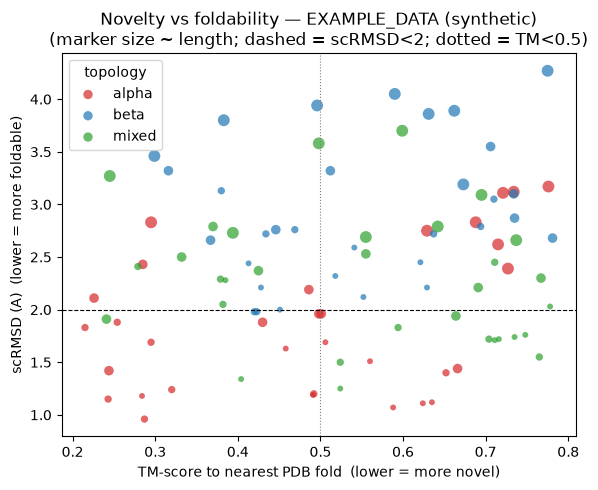

foldable & novel (lower-left): 17 / 96


In [24]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import rfdiff_tools as rt

bb = pd.read_csv("results/backbones.csv")
synthetic = bool(bb.get("synthetic", pd.Series([False])).any())
tag = "EXAMPLE_DATA (synthetic)" if synthetic else "real designs"

colors = {"alpha": "tab:red", "beta": "tab:blue", "mixed": "tab:green"}
fig, ax = plt.subplots(figsize=(6, 5))
for ss, g in bb.groupby("ss_bias"):
    ax.scatter(g["tm_to_pdb"], g["scrmsd"], s=18 + (g["length"] - 80) / 4,
               c=colors.get(ss, "gray"), alpha=0.7, label=ss, edgecolors="none")
ax.axhline(rt.SELF_CONSISTENT_SCRMSD, ls="--", c="k", lw=0.8)
ax.axvline(rt.NOVEL_TM, ls=":", c="gray", lw=0.8)
ax.set_xlabel("TM-score to nearest PDB fold  (lower = more novel)")
ax.set_ylabel("scRMSD (A)  (lower = more foldable)")
ax.set_title(f"Novelty vs foldability — {tag}\n(marker size ~ length; dashed = scRMSD<2; dotted = TM<0.5)")
ax.legend(title="topology")
plt.tight_layout(); plt.savefig("results/frontier.png", dpi=150); plt.show()
print("foldable & novel (lower-left):",
      int(((bb.scrmsd < rt.SELF_CONSISTENT_SCRMSD) & (bb.tm_to_pdb < rt.NOVEL_TM)).sum()), "/", len(bb))

## 2 · The Pareto frontier explicitly

Extract the non-dominated set: a design is on the frontier if no other design is both more novel
(lower TM) **and** more foldable (lower scRMSD). Reading the lowest TM achievable at scRMSD < 2 Å off
this set gives the raw material for the **novelty budget** (notebook 05).

In [25]:
def pareto_front(df, x="tm_to_pdb", y="scrmsd"):
    """Non-dominated set minimizing BOTH x (TM, want low=novel) and y (scRMSD, want low=foldable)."""
    pts = df[[x, y]].dropna().sort_values([x, y]).values
    front, best_y = [], np.inf
    for xi, yi in pts:
        if yi < best_y:                 # strictly better foldability as we move to higher novelty
            front.append((xi, yi)); best_y = yi
    return pd.DataFrame(front, columns=[x, y])

front = pareto_front(bb)
print("Pareto frontier points (TM, scRMSD):")
print(front.round(3).to_string(index=False))
foldable_front = front[front["scrmsd"] < rt.SELF_CONSISTENT_SCRMSD]
if len(foldable_front):
    print(f"\nMost novel still foldable: TM={foldable_front['tm_to_pdb'].min():.3f} "
          f"at scRMSD={foldable_front.loc[foldable_front['tm_to_pdb'].idxmin(),'scrmsd']:.2f} A")

Pareto frontier points (TM, scRMSD):
 tm_to_pdb  scrmsd
     0.215    1.83
     0.243    1.15
     0.287    0.96

Most novel still foldable: TM=0.215 at scRMSD=1.83 A


## 3 · Per-topology and per-length success rates

The honest hit-rate table: fraction with scRMSD < 2 Å in each (topology × length) cell. Expect the
characteristic pattern — high for short all-α, collapsing toward long all-β. Caption every figure
with the metric, cutoff, and N.

Foldable rate (scRMSD < 2 A) by topology x length  [ EXAMPLE_DATA (synthetic) ]:
                mean  count
ss_bias length             
alpha   80      1.00      8
        120     1.00      8
        200     0.62      8
        300     0.00      8
beta    80      0.00      8
        120     0.25      8
        200     0.00      8
        300     0.00      8
mixed   80      0.75      8
        120     0.50      8
        200     0.25      8
        300     0.00      8


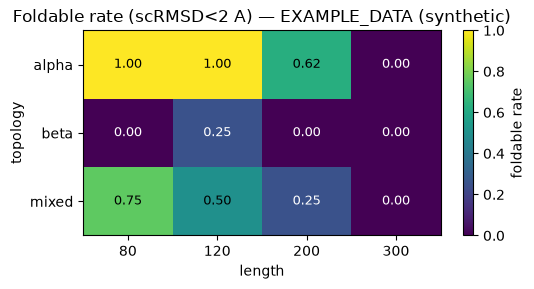

In [26]:
bb["foldable"] = bb["scrmsd"] < rt.SELF_CONSISTENT_SCRMSD
rate = bb.groupby(["ss_bias", "length"])["foldable"].agg(["mean", "count"])
print("Foldable rate (scRMSD < 2 A) by topology x length  [", tag, "]:")
print(rate.assign(mean=rate["mean"].round(2)))

pivot = bb.groupby(["ss_bias", "length"])["foldable"].mean().unstack("length")
fig, ax = plt.subplots(figsize=(5.5, 3))
im = ax.imshow(pivot.values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("length"); ax.set_ylabel("topology")
ax.set_title(f"Foldable rate (scRMSD<2 A) — {tag}")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, "" if np.isnan(v) else f"{v:.2f}", ha="center", va="center",
                color="w" if (np.isnan(v) or v < 0.5) else "k", fontsize=9)
fig.colorbar(im, ax=ax, label="foldable rate")
plt.tight_layout(); plt.savefig("results/success_heatmap.png", dpi=150); plt.show()

## 4 · Tool comparison scaffold — RFdiffusion / FrameFlow / Genie2 `[extension]`

Compare generators on **diversity, speed, and foldability**. This is a *scaffold*: run each tool on
the same grid and fill the table from **your own measurements**. **Do NOT fabricate numbers** — the
cells below are `None`/`NaN` until you measure them. The mock backend cannot stand in for a real
generator comparison.

In [27]:
import pandas as pd
# Fill ONLY from your own runs. Leave NaN until measured — never invent a generator's numbers.
comparison = pd.DataFrame({
    "tool":            ["RFdiffusion", "FrameFlow", "Genie2"],
    "foldable_rate":   [None, None, None],   # frac scRMSD<2 on the SAME grid (you measure)
    "median_tm_to_pdb":[None, None, None],   # novelty (you measure)
    "diversity":       [None, None, None],   # e.g. mean pairwise TM among designs (you measure)
    "sec_per_backbone":[None, None, None],   # wall-clock on YOUR GPU (you measure)
})
comparison.to_csv("results/tool_comparison.csv", index=False)
print("Tool-comparison scaffold (UNMEASURED — fill from your own runs, do not fabricate):")
print(comparison.to_string(index=False))

Tool-comparison scaffold (UNMEASURED — fill from your own runs, do not fabricate):
       tool foldable_rate median_tm_to_pdb diversity sec_per_backbone
RFdiffusion          None             None      None             None
  FrameFlow          None             None      None             None
     Genie2          None             None      None             None


## D3 (part 2) checklist
- [ ] Novelty-vs-scRMSD frontier figure (lower-left = novel & foldable), with N and cutoffs captioned.
- [ ] Explicit Pareto frontier + the most-novel-still-foldable point identified.
- [ ] Per-topology AND per-length success-rate table/heatmap (honest, including the failure cells).
- [ ] Tool-comparison scaffold filled from **your own** RFdiffusion/FrameFlow/Genie2 runs (or left blank, not fabricated).
- [ ] Failure-mode notes: where does foldability collapse, and why (length / β-register)?

**Next:** `05_validation_plan.ipynb` — novelty budget + synthesis plan with paired controls.

---

## ▶︎ Section 6 / 6 — `05_validation_plan.ipynb`

---

# 05 · Validation plan — novelty budget + synthesis plan with paired controls

**Standard slot:** *validation plan.* **For Project 03 this means:** convert the frontier into a
**"novelty budget"** guideline (D★), select a **novel-but-foldable set**, and write a costed
synthesis/expression plan whose controls are a **HIGH-novelty risky design paired with a conservative
design**, plus an unrelated control (D4/D5). Optional: a short MD stability check on top picks.

## Setup paths

In [28]:
import sys, os
# Make the project's scripts/ and the cohort's shared/ importable.
# Adjust these if your Colab working directory differs (see 00_setup §5 for Drive mounting).
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_03_rfdiffusion_monomer/notebooks


## 1 · Derive the novelty budget

From the frontier (nb 04), state — **per topology and length band** — the most novelty (lowest TM to
the PDB) you can spend while keeping scRMSD < 2 Å. That is the budget: a practical rule for "how far
from natural fold space you can push this topology/length before foldability collapses." 

In [29]:
import pandas as pd, numpy as np
import rfdiff_tools as rt

bb = pd.read_csv("results/backbones.csv")
foldable = bb[bb["scrmsd"] < rt.SELF_CONSISTENT_SCRMSD]

# Novelty budget = lowest TM (most novel) still foldable, per topology (and length band).
budget = (foldable.groupby("ss_bias")
          .agg(min_tm_foldable=("tm_to_pdb", "min"),
               median_tm_foldable=("tm_to_pdb", "median"),
               n_foldable=("tm_to_pdb", "size")).round(3))
print("NOVELTY BUDGET (lower min_tm = more novelty affordable while still foldable):")
print(budget)
print("\nRule of thumb to state in your thesis (fill from YOUR data, not the synthetic mock):")
print("  e.g. 'all-alpha tolerates TM down to ~X at L<=120; all-beta only to ~Y; long backbones less.'")

NOVELTY BUDGET (lower min_tm = more novelty affordable while still foldable):
         min_tm_foldable  median_tm_foldable  n_foldable
ss_bias                                                 
alpha              0.215               0.491          21
beta               0.420               0.422           2
mixed              0.241               0.684          12

Rule of thumb to state in your thesis (fill from YOUR data, not the synthetic mock):
  e.g. 'all-alpha tolerates TM down to ~X at L<=120; all-beta only to ~Y; long backbones less.'


## 2 · Select the novel-but-foldable set (D★)

Pick the designs that are both foldable (scRMSD < 2 Å) and genuinely novel (TM < 0.5), ranked by a
simple novelty-weighted-foldability score. **On the mock backend these are synthetic `EXAMPLE_DATA`
ids** — replace with your real RFdiffusion designs for the actual synthesis list.

In [30]:
cand = bb[(bb["scrmsd"] < rt.SELF_CONSISTENT_SCRMSD) & (bb["tm_to_pdb"] < rt.NOVEL_TM)].copy()
# score: reward low scRMSD AND low TM (more novel). Tune weights for your priorities.
cand["pick_score"] = (rt.SELF_CONSISTENT_SCRMSD - cand["scrmsd"]) + (rt.NOVEL_TM - cand["tm_to_pdb"])
selected = cand.sort_values("pick_score", ascending=False).head(8)
selected.to_csv("results/selected_novel_foldable.csv", index=False)
print("Selected novel-but-foldable set (label EXAMPLE_DATA if synthetic):")
print(selected[["backbone_id", "length", "ss_bias", "scrmsd", "plddt", "tm_to_pdb"]].to_string(index=False))

Selected novel-but-foldable set (label EXAMPLE_DATA if synthetic):
                backbone_id  length ss_bias  scrmsd  plddt  tm_to_pdb
EXAMPLE_DATA_alpha_L120_006     120   alpha    0.96   90.0      0.287
EXAMPLE_DATA_alpha_L120_000     120   alpha    1.15   87.7      0.243
 EXAMPLE_DATA_alpha_L80_005      80   alpha    1.18   86.4      0.284
EXAMPLE_DATA_alpha_L120_002     120   alpha    1.24   86.6      0.320
EXAMPLE_DATA_alpha_L200_006     200   alpha    1.42   86.0      0.244
 EXAMPLE_DATA_alpha_L80_003      80   alpha    1.19   86.3      0.491
EXAMPLE_DATA_alpha_L120_007     120   alpha    1.20   87.0      0.492
 EXAMPLE_DATA_mixed_L80_001      80   mixed    1.34   86.1      0.404


## 3 · The synthesis / expression plan with PAIRED controls

Controls are mandatory and, for this project, **paired by novelty** — that pairing is what tests
whether the novelty budget holds up experimentally.

In [31]:
plan = """# Synthesis & Expression Plan (Project 03 — by <name>, <date>)

## Designs to synthesize (codon-optimized, gene synthesis via an IGSC-screening provider)
1. TEST    — one HIGH-novelty design (lowest TM, scRMSD<2): the risky case.
2. CONTROL+ — one CONSERVATIVE design (high TM ~>0.6, very low scRMSD, high pLDDT): expected to fold.
3. CONTROL- — an UNRELATED natural protein of similar size (e.g., a small natural monomer): orthogonal control.
   (The risky vs conservative PAIR directly tests the novelty budget.)

## Expression
- Host: E. coli BL21(DE3); T7 vector; His6 tag + TEV site; 16-18 C overnight induction.
- Note: switch to a refolding protocol or mammalian expression only if the novel design is insoluble.

## Characterization (go/no-go -> basic -> deep)
- go/no-go : express -> SDS-PAGE (right MW?) -> SEC (monodisperse monomer?).
- basic    : CD (secondary-structure content vs the DESIGNED topology), DSF (Tm / thermostability).
- deep     : crystallography or cryo-EM to CONFIRM the novel fold; SEC-MALS / SAXS for solution shape.

## Read-out tied to the hypothesis
- Does the HIGH-novelty design fold (SEC monomer + CD matching topology) as well as the conservative one?
- If the conservative folds and the novel does not, the novelty budget was exceeded for that topology/length.

## Controls, timeline, cost
- Controls: positive (conservative design), negative (unrelated protein); both run in parallel.
- Timeline: synthesis ~2-3 wk; expression/purification ~2 wk; characterization ~3-4 wk.
- Cost: gene synthesis (3 constructs) + expression reagents + SEC/CD/DSF time — itemize for your advisor.

## Responsible research
- Low dual-use: novel monomers with no designed function. Synthesis through an IGSC-screening provider;
  institutional biosafety/ethics approval before any wet-lab work. Re-evaluate under MASTER_BLUEPRINT §7
  if a fold is later repurposed toward a functional target.
"""
open("results/synthesis_plan.md", "w").write(plan)
print("wrote results/synthesis_plan.md — fill <name>/<date> and the costed reagent list.")

wrote results/synthesis_plan.md — fill <name>/<date> and the costed reagent list.


## 4 · (Stretch) Short MD stability check on top picks `[stretch]`

Run a short MD (OpenMM, ~10–50 ns) on the top picks and check the backbone doesn't drift far from the
designed structure (`md_rmsd`). Feed `md_rmsd` into the shared filter's Layer 4 (`dynamics_filter`)
for an extra confidence layer on the designs you'll actually synthesize. This is a **scaffold** —
implement on a GPU runtime; it does not run on the mock backend.

In [32]:
# OpenMM scaffold (GPU runtime; small systems feasible on T4, long MD -> HPC). Illustrative only.
#
#   # for a top-pick PDB:
#   from openmm.app import PDBFile, ForceField, Modeller, Simulation, PME, HBonds
#   from openmm import LangevinMiddleIntegrator, unit
#   pdb = PDBFile("results/backbones/<top_pick>.pdb")
#   ff = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")
#   # ... solvate, minimize, equilibrate, run 10-50 ns, compute backbone RMSD vs frame 0 ...
#   md_rmsd = ...  # mean backbone RMSD over the trajectory (A)
#
# then feed into the shared filter's Layer 4:
#   import filtering_pipeline as fp
#   d = fp.Design(design_id="top_pick", sequence="...", design_type="monomer",
#                 scrmsd=..., plddt=..., md_rmsd=md_rmsd)
#   fp.dynamics_filter(d, max_md_rmsd=3.0)   # stable if the fold doesn't drift
print("Stretch task — run OpenMM on top picks (GPU); feed md_rmsd into fp.dynamics_filter (Layer 4).")

Stretch task — run OpenMM on top picks (GPU); feed md_rmsd into fp.dynamics_filter (Layer 4).


## D4 / D5 checklist
- [ ] **Novelty budget** guideline derived from the frontier, per topology/length (D★).
- [ ] `results/selected_novel_foldable.csv`: the novel-but-foldable set (real designs, not EXAMPLE_DATA, for synthesis).
- [ ] `results/synthesis_plan.md`: paired HIGH-novelty vs conservative controls + unrelated control, costed + timed.
- [ ] (Stretch) short MD stability check on top picks; `md_rmsd` fed into Layer 4.
- [ ] Thesis chapter + 15-min talk + `v1.0` tagged release including the novelty-budget guideline.

You're done — you've mapped the novelty–foldability frontier and turned it into a budget the cohort can use.